In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n=50

df=pd.DataFrame({
    # Nominal 
    'Gender':np.random.choice(['Male','Female'],n),
    "Color":np.random.choice(['Green','Yellow','Blue','Red'],50),

    # Ordinal
    "Education":np.random.choice(['high_school','BTech','MTech','PHD'],n),
    "Satisfaction":np.random.choice(['Low','Medium','High'],n),

    # Binary
    'HashCar':np.random.choice([0,1],n),
    # High Cardinality
    'City':np.random.choice([f'City_{i}' for i in range(1,11)],n)
})
df.head(10)

,Gender,Color,Education,Satisfaction,HashCar,City
0,Male,Blue,MTech,High,0,City_5
1,Female,Yellow,BTech,High,0,City_1
2,Male,Blue,BTech,Low,0,City_3
3,Male,Red,PHD,High,0,City_10
4,Male,Blue,BTech,Low,1,City_8
5,Female,Red,BTech,Medium,0,City_6
6,Male,Red,BTech,High,1,City_8
7,Male,Green,PHD,Medium,0,City_9
8,Male,Blue,BTech,Low,0,City_4
9,Female,Green,MTech,High,0,City_1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Gender        50 non-null     str  
 1   Color         50 non-null     str  
 2   Education     50 non-null     str  
 3   Satisfaction  50 non-null     str  
 4   HashCar       50 non-null     int64
 5   City          50 non-null     str  
dtypes: int64(1), str(5)
memory usage: 2.5 KB


In [20]:
df['Education'].value_counts()

Education
PHD            16
high_school    14
MTech          10
BTech          10
Name: count, dtype: int64

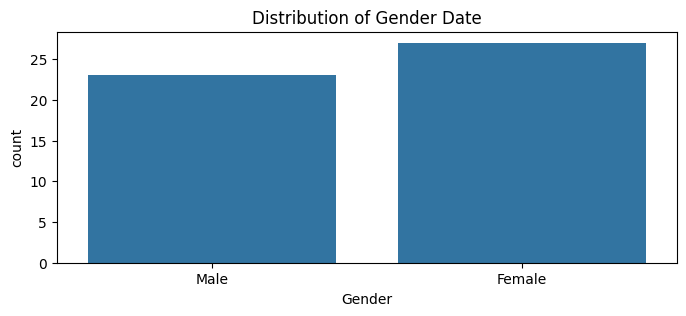

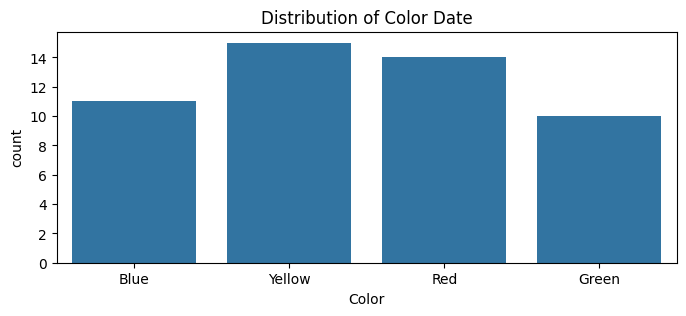

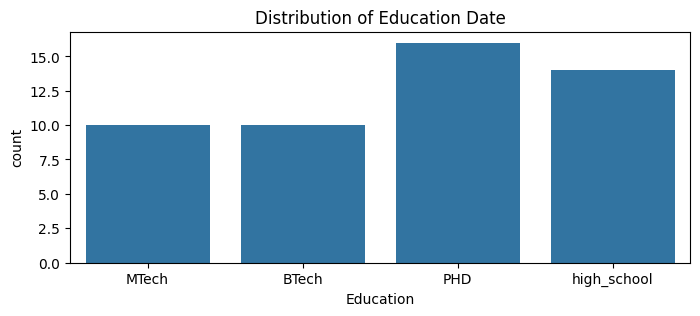

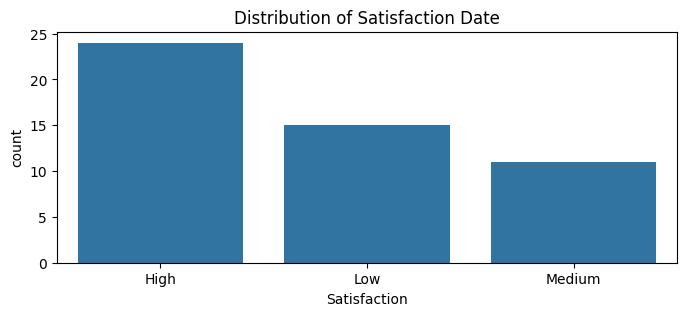

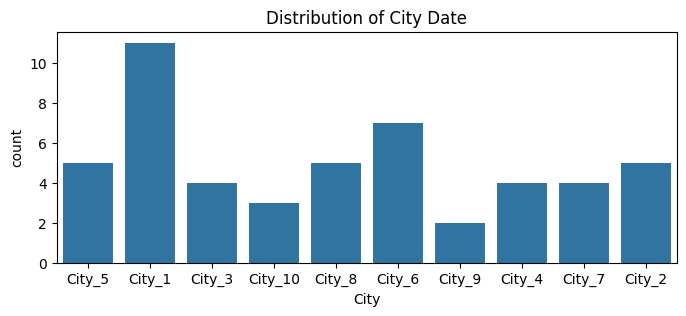

In [23]:
cat_cols=df.select_dtypes(include='str').columns

for label in cat_cols:
    plt.figure(figsize=(8,3))
    sns.countplot(x=label,data=df)
    plt.title(f'Distribution of {label} Date')
    plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder

print(cat_cols)

Index(['Gender', 'Color', 'Education', 'Satisfaction', 'City'], dtype='str')


LabelEncoder

In [ ]:
le=LabelEncoder()


OrdinalEncoder

In [44]:
ordinal_col=['Education','Satisfaction']

educational_order=['high_school','BTech','MTech','PHD']
satisfaction_order=['Low','Medium','High']

ordinal_encoder=OrdinalEncoder(categories=[educational_order,satisfaction_order])
oridnal_encoded=ordinal_encoder.fit_transform(df[ordinal_col])
df_ordinal_encoded=pd.DataFrame(data=oridnal_encoded,columns=[f"{c}_encoded" for c in ordinal_col])
df_ordinal_encoded.head()
df.head()


,Gender,Color,Education,Satisfaction,HashCar,City,Education_encoded,Satisfaction_encoded,Education_encoded,Satisfaction_encoded,Education_encoded,Satisfaction_encoded
0,Male,Blue,MTech,High,0,City_5,2.0,2.0,2.0,2.0,2.0,2.0
1,Female,Yellow,BTech,High,0,City_1,1.0,2.0,1.0,2.0,1.0,2.0
2,Male,Blue,BTech,Low,0,City_3,1.0,0.0,1.0,0.0,1.0,0.0
3,Male,Red,PHD,High,0,City_10,3.0,2.0,3.0,2.0,3.0,2.0
4,Male,Blue,BTech,Low,1,City_8,1.0,0.0,1.0,0.0,1.0,0.0


One Hot Encoding

In [45]:
np.random.seed(42)

n=50

df=pd.DataFrame({
    # Nominal 
    'Gender':np.random.choice(['Male','Female'],n),
    "Color":np.random.choice(['Green','Yellow','Blue','Red'],50),

    # Ordinal
    "Education":np.random.choice(['high_school','BTech','MTech','PHD'],n),
    "Satisfaction":np.random.choice(['Low','Medium','High'],n),

    # Binary
    'HashCar':np.random.choice([0,1],n),
    # High Cardinality
    'City':np.random.choice([f'City_{i}' for i in range(1,11)],n)
})
df.head(10)

,Gender,Color,Education,Satisfaction,HashCar,City
0,Male,Blue,MTech,High,0,City_5
1,Female,Yellow,BTech,High,0,City_1
2,Male,Blue,BTech,Low,0,City_3
3,Male,Red,PHD,High,0,City_10
4,Male,Blue,BTech,Low,1,City_8
5,Female,Red,BTech,Medium,0,City_6
6,Male,Red,BTech,High,1,City_8
7,Male,Green,PHD,Medium,0,City_9
8,Male,Blue,BTech,Low,0,City_4
9,Female,Green,MTech,High,0,City_1


In [49]:
nominal_cols=['Gender','Color']
ohe_nominal=OneHotEncoder(drop='first',sparse_output=False)
nominal_encoded=ohe_nominal.fit_transform(df[nominal_cols])
df_nominal_encoded=pd.DataFrame(nominal_encoded,columns=ohe_nominal.get_feature_names_out(nominal_cols))
df_nominal_encoded.head()

,Gender_Male,Color_Green,Color_Red,Color_Yellow
0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0


In [ ]:
df=pd.concat([df,df_nominal_encoded],axis=1)
df.drop(['Gender','Color'],axis=1,inplace=True)
df


KeyError: "['Gender' 'Color'] not found in axis"

In [58]:
df.head()

,Education,Satisfaction,HashCar,City,Gender_Male,Color_Green,Color_Red,Color_Yellow,Gender_Male,Color_Green,...,Color_Red,Color_Yellow,Gender_Male,Color_Green,Color_Red,Color_Yellow,Gender_Male,Color_Green,Color_Red,Color_Yellow
0,MTech,High,0,City_5,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,BTech,High,0,City_1,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,BTech,Low,0,City_3,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,PHD,High,0,City_10,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,BTech,Low,1,City_8,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
